## **0. Download dataset**
**Note:** If you can't download using gdown due to limited number of downloads, please download it manually and upload it to your drive, then copy it from the drive to colab.
```python
from google.colab import drive

drive.mount('/content/drive')
!cp /path/to/dataset/on/your/drive .
```

In [1]:
# https://drive.google.com/file/d/13Dlv9Ze336Od8hkd-R8Teb2nEGFRdeHP/view?usp=drive_link
#!gdown --id 13Dlv9Ze336Od8hkd-R8Teb2nEGFRdeHP

In [2]:
#!unzip '[Data]-card-fraud-detection.zip'

## **1. Import libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

## **2. Read dataset**

In [4]:
dataset_path = '../Data/creditcard.csv'
df = pd.read_csv(
    dataset_path
)
df

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
print("Proportion of samples where class = 0:", np.mean(df["Class"] == 0))
print("Proportion of samples where class = 1:", np.mean(df["Class"] == 1))

Proportion of samples where class = 0: 0.9982725143693799
Proportion of samples where class = 1: 0.001727485630620034


In [7]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


## **3. Add bias term**

In [8]:
dataset_arr = df.to_numpy()
X, y = dataset_arr[:, :-1].astype(np.float64), dataset_arr[:, -1].astype(np.uint8)

In [9]:
np.unique(y)

array([0, 1], dtype=uint8)

In [10]:
dataset_arr = df.to_numpy()

In [11]:
print(X.shape)

(284807, 30)


In [12]:
intercept = np.ones((
    X.shape[0], 1)
)
X_b = np.concatenate(
    (intercept, X),
    axis=1
)

In [13]:
print(X_b.shape)

(284807, 31)


## **4. One-hot encoding label**

In [14]:
n_classes = np.unique(y, axis=0).shape[0]
n_samples = y.shape[0]

#y_encoded = np.array(
#    [np.zeros(n_classes) for _ in range(n_samples)]
#)
y_encoded = np.zeros((n_samples, n_classes))
y_encoded[np.arange(n_samples), y] = 1

## **5. Split train, val, test set**

In [15]:
val_size = 0.2
test_size = 0.125
random_state = 2
is_shuffle = True

X_train, X_val, y_train, y_val = train_test_split(
    X_b, y_encoded,
    test_size=val_size,
    random_state=random_state,
    shuffle=is_shuffle
)

X_train, X_test, y_train, y_test = train_test_split(
    X_train, y_train,
    test_size=test_size,
    random_state=random_state,
    shuffle=is_shuffle
)

In [16]:
print(f'Number of training samples: {X_train.shape[0]}')
print(f'Number of val samples: {X_val.shape[0]}')
print(f'Number of test samples: {X_test.shape[0]}')

Number of training samples: 199364
Number of val samples: 56962
Number of test samples: 28481


## **6. Normalization**

In [17]:
normalizer = StandardScaler()
X_train[:, 1:] = normalizer.fit_transform(X_train[:, 1:])
X_val[:, 1:] = normalizer.transform(X_val[:, 1:])
X_test[:, 1:] = normalizer.transform(X_test[:, 1:])

### **6.5. Handle Imbalanced Data with SMOTE**

In [18]:
# Resample training data to balance classes
smote = SMOTE(random_state=random_state, sampling_strategy='minority')
X_train_balanced, y_train_balanced = smote.fit_resample(X_train[:, 1:], 
                                                        np.argmax(y_train, axis=1) # Label Encoding the One-hot encoded matrix
                                                                                   # -> Return an array 
                                                        )

# Re-add intercept term
intercept_balanced = np.ones((X_train_balanced.shape[0], 1))
X_train = np.concatenate((intercept_balanced, X_train_balanced), axis=1)

# Re-encode labels to one-hot
y_train = np.array([np.zeros(n_classes) for _ in range(y_train_balanced.shape[0])])
y_train[np.arange(y_train_balanced.shape[0]), y_train_balanced] = 1

# Verify new distribution
print(f'Balanced training samples: {X_train.shape[0]}')
print(f'Class distribution: {np.bincount(y_train_balanced)}')

Balanced training samples: 398002
Class distribution: [199001 199001]


In [19]:
X_train

array([[ 1.        , -0.68101315,  0.71447649, ...,  0.1019486 ,
         0.07410031, -0.29192049],
       [ 1.        ,  1.04720051,  1.0475128 , ..., -0.19095883,
        -0.09813199, -0.27780616],
       [ 1.        ,  1.54445364, -1.20352757, ...,  0.31391593,
         1.12488897, -0.34496952],
       ...,
       [ 1.        ,  0.86681249, -1.80351772, ..., -2.8881391 ,
         1.19656217,  0.00738136],
       [ 1.        ,  1.14262225, -0.53304231, ...,  1.57192248,
         1.15765039, -0.00520879],
       [ 1.        , -0.89535081, -0.86109348, ...,  0.92494536,
         0.36676226,  0.26471862]], shape=(398002, 31))

# Bắt đầu bài tập code - Thay thế code vào phần Your Code Here



## **7. Define essential functions**

### **7.1. Softmax Function**

In [20]:
def softmax(z):
    exp_z = np.exp(z) # Your code here
    # The None keyword here acts as alias for np.newaxis, 
    # which creates a new axis next to ":" - all the elements in the array
    # -> shape (len(z), 1)

    return exp_z / np.sum(exp_z, axis=1)[:, None]  # Your code here

### **7.2. Hypothesis function**

In [21]:
def predict(X, theta) -> np.ndarray:
    z = X @ theta # Your code here
    y_hat = softmax(z) # Your code here

    return y_hat # Your code here

### **7.3. Cross-entropy loss function**

In [22]:
def compute_loss(y_hat: np.ndarray, y: np.ndarray):
    n = len(y) # Your code here

    return -1/n * np.sum(np.log(y_hat) * y) # Your code here
           # Only sums up the probabilities of the ground truth for each sample
           # since other indexes are 0

### **7.4. Gradient function**

In [23]:
def compute_gradient(X, y, y_hat):
    n = len(y) # Your code here

    return 1/n * (X.T @ (y_hat - y))  # Your code here

### **7.5. Update weights function**

In [24]:
def update_theta(theta, gradient, lr):
    return theta - lr*gradient # Your code here

### **7.6. Accuracy function**

In [25]:
def compute_accuracy(X: np.ndarray, y: np.ndarray, theta: np.ndarray):
    y_hat = predict(X, theta) # Your code here
    acc = np.mean(y.argmax(axis=1) == y_hat.argmax(axis=1)) # Your code here

    return acc

# Done bài tập code - Phần sau chỉ cần đọc và Run Cell

## **8. Training**

In [26]:
lr = 0.01
epochs = 30
batch_size = 1024
n_features = X_train.shape[1]

# Khởi tạo ngẫu nhiên tham số mô hình
np.random.seed(random_state)
theta = np.random.uniform(
    size=(n_features, n_classes)
)

In [27]:
# Lưu lịch sử huấn luyện
train_accs = []
train_losses = []
val_accs = []
val_losses = []

for epoch in range(epochs):
    train_batch_losses = []
    train_batch_accs = []
    val_batch_losses = []
    val_batch_accs = []

    for i in range(0, X_train.shape[0], batch_size):
        # Lấy mini-batch
        X_i = X_train[i:i+batch_size]
        y_i = y_train[i:i+batch_size]

        # Dự đoán và tính mất mát
        y_hat = predict(X_i, theta)
        train_loss = compute_loss(y_hat, y_i)

        # Tính gradient và cập nhật tham số
        gradient = compute_gradient(X_i, y_i, y_hat)
        theta = update_theta(theta, gradient, lr)

        # Ghi nhận kết quả batch huấn luyện
        train_batch_losses.append(train_loss)
        train_acc = compute_accuracy(X_train, y_train, theta)
        train_batch_accs.append(train_acc)

        # Tính mất mát và độ chính xác trên tập kiểm định
        y_val_hat = predict(X_val, theta)
        val_loss = compute_loss(y_val_hat, y_val)
        val_batch_losses.append(val_loss)

        val_acc = compute_accuracy(X_val, y_val, theta)
        val_batch_accs.append(val_acc)

    # Tính trung các chỉ số theo batch
    train_batch_loss = sum(train_batch_losses) / len(train_batch_losses)
    val_batch_loss = sum(val_batch_losses) / len(val_batch_losses)
    train_batch_acc = sum(train_batch_accs) / len(train_batch_accs)
    val_batch_acc = sum(val_batch_accs) / len(val_batch_accs)

    # Lưu lịch sử qua từng epoch
    train_losses.append(train_batch_loss)
    val_losses.append(val_batch_loss)
    train_accs.append(train_batch_acc)
    val_accs.append(val_batch_acc)

    print(f'\nEPOCH {epoch + 1}:\tTraining loss: {train_batch_loss:.3f}\tValidation loss: {val_batch_loss:.3f}')


EPOCH 1:	Training loss: 0.316	Validation loss: 0.401

EPOCH 2:	Training loss: 0.197	Validation loss: 0.235

EPOCH 3:	Training loss: 0.162	Validation loss: 0.181

EPOCH 4:	Training loss: 0.149	Validation loss: 0.159

EPOCH 5:	Training loss: 0.143	Validation loss: 0.148

EPOCH 6:	Training loss: 0.139	Validation loss: 0.141

EPOCH 7:	Training loss: 0.137	Validation loss: 0.136

EPOCH 8:	Training loss: 0.135	Validation loss: 0.132

EPOCH 9:	Training loss: 0.134	Validation loss: 0.129

EPOCH 10:	Training loss: 0.133	Validation loss: 0.127

EPOCH 11:	Training loss: 0.132	Validation loss: 0.125

EPOCH 12:	Training loss: 0.132	Validation loss: 0.124

EPOCH 13:	Training loss: 0.131	Validation loss: 0.123

EPOCH 14:	Training loss: 0.131	Validation loss: 0.122

EPOCH 15:	Training loss: 0.130	Validation loss: 0.121

EPOCH 16:	Training loss: 0.130	Validation loss: 0.120

EPOCH 17:	Training loss: 0.130	Validation loss: 0.119

EPOCH 18:	Training loss: 0.129	Validation loss: 0.119

EPOCH 19:	Training

In [28]:
train_accs

[np.float64(0.8919923397834916),
 np.float64(0.9355677689751825),
 np.float64(0.941963907920577),
 np.float64(0.9441395503186232),
 np.float64(0.9452545800463538),
 np.float64(0.9459726397623482),
 np.float64(0.9465188642978614),
 np.float64(0.9469434594436733),
 np.float64(0.9472961271887272),
 np.float64(0.9475930537817888),
 np.float64(0.9478488946891268),
 np.float64(0.9480678611773783),
 np.float64(0.9482508962602385),
 np.float64(0.9484103172467301),
 np.float64(0.9485497347166838),
 np.float64(0.9486730563638394),
 np.float64(0.9487856819104475),
 np.float64(0.9488877340774752),
 np.float64(0.9489823454789067),
 np.float64(0.9490708014553257),
 np.float64(0.9491514032902829),
 np.float64(0.9492274386137164),
 np.float64(0.9492984165417833),
 np.float64(0.9493661262169061),
 np.float64(0.9494291208235526),
 np.float64(0.9494903327467739),
 np.float64(0.9495477209432325),
 np.float64(0.9496015308548468),
 np.float64(0.9496534095260836),
 np.float64(0.9497031567280113)]

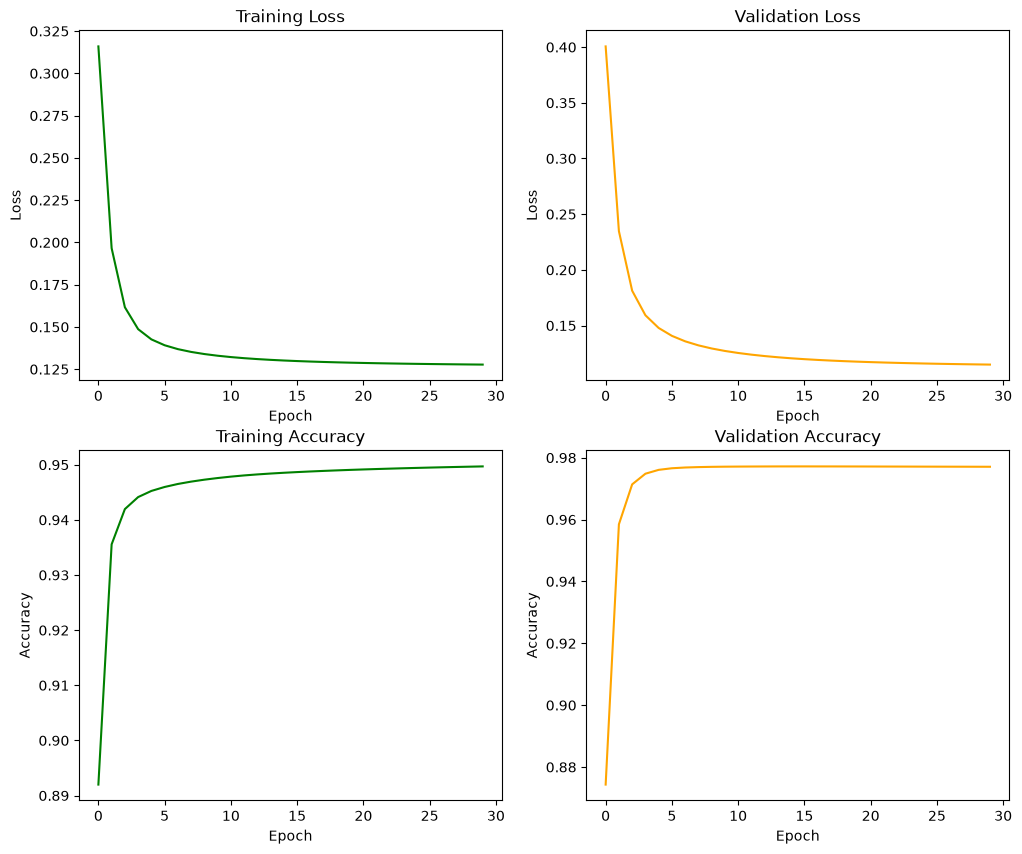

In [29]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10))
ax[0, 0].plot(train_losses, color='green')
ax[0, 0].set(xlabel='Epoch', ylabel='Loss')
ax[0, 0].set_title('Training Loss')

ax[0, 1].plot(val_losses, color='orange')
ax[0, 1].set(xlabel='Epoch', ylabel='Loss')
ax[0, 1].set_title('Validation Loss')

ax[1, 0].plot(train_accs, color='green')
ax[1, 0].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 0].set_title('Training Accuracy')

ax[1, 1].plot(val_accs, color='orange')
ax[1, 1].set(xlabel='Epoch', ylabel='Accuracy')
ax[1, 1].set_title('Validation Accuracy')

plt.show()

## **9. Evaluation**

In [30]:
# Val set
val_set_acc = compute_accuracy(X_val, y_val, theta)
print('Evaluation on validation set:')
print(f'Accuracy: {val_set_acc}')

Evaluation on validation set:
Accuracy: 0.9652575401144623


In [31]:
# Test set
test_set_acc = compute_accuracy(X_test, y_test, theta)
print('Evaluation on test set:')
print(f'Accuracy: {test_set_acc}')

Evaluation on test set:
Accuracy: 0.9660826515922896
